In [10]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import h5py

In [45]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix

print(tf.__version__)

2.18.0


In [12]:
DATA_DIR = '/kaggle/input/jrl780-a2'

train_x_path = os.path.join(DATA_DIR, 'camelyonpatch_level_2_split_train_x.h5')
train_y_path = os.path.join(DATA_DIR, 'camelyonpatch_level_2_split_train_y.h5')

valid_x_path = os.path.join(DATA_DIR, 'camelyonpatch_level_2_split_valid_x.h5')
valid_y_path = os.path.join(DATA_DIR, 'camelyonpatch_level_2_split_valid_y.h5')

test_x_path = os.path.join(DATA_DIR, 'camelyonpatch_level_2_split_test_x.h5')
test_y_path = os.path.join(DATA_DIR, 'camelyonpatch_level_2_split_test_y.h5')

print("Paths set. Checking if files exist...")
print(f"Train X exists: {os.path.exists(train_x_path)}")
print(f"Train Y exists: {os.path.exists(train_y_path)}")

Paths set. Checking if files exist...
Train X exists: True
Train Y exists: True


In [25]:
import threading

class H5DataGenerator(tf.keras.utils.Sequence):
    def __init__(self, x_path, y_path, batch_size=64, shuffle=True, augment=False):
        self.x_path = x_path
        self.y_path = y_path
        self.batch_size = batch_size
        self.shuffle = shuffle
        
        try:
            self.hfx = h5py.File(self.x_path, 'r')
            self.hfy = h5py.File(self.y_path, 'r')
            self.n_samples = self.hfx['x'].shape[0]
            self.lock = threading.Lock() 
        except Exception as e:
            print(f"Error opening H5 files: {e}")
            self.hfx = None
            self.hfy = None
            self.n_samples = 0
            
        self.indexes = np.arange(self.n_samples)
        if self.shuffle:
            np.random.shuffle(self.indexes)
            
    def __del__(self):
        if self.hfx:
            try:
                self.hfx.close()
            except:
                pass
        if self.hfy:
            try:
                self.hfy.close()
            except:
                pass

    def __len__(self):
        return int(np.ceil(self.n_samples / self.batch_size))

    def get_batch(self, index):
        start_index = index * self.batch_size
        end_index = min((index + 1) * self.batch_size, self.n_samples)
        batch_indexes = self.indexes[start_index:end_index]
        
        try:
            with self.lock:
                sorted_batch_indexes = np.sort(batch_indexes)
                
                batch_x = self.hfx['x'][sorted_batch_indexes]
                batch_y = self.hfy['y'][sorted_batch_indexes]
        except Exception as e:
            print(f"Error reading H5 batch at index {index}: {e}")
            batch_x = np.empty((0, 96, 96, 3), dtype='float32')
            batch_y = np.empty((0, 1), dtype='float32')
            return batch_x, batch_y
        
        batch_x = batch_x.astype('float32') / 255.0
        
        batch_y = batch_y.flatten().reshape(-1, 1).astype('float32')

        return batch_x, batch_y

def create_dataset_from_generator(data_gen, prefetch=True, repeat=True):
    def generator():
        for i in range(len(data_gen)):
            yield data_gen.get_batch(i)

    dataset = tf.data.Dataset.from_generator(
        generator,
        output_types=(tf.float32, tf.float32), # Changed y to float32
        output_shapes=([None, 96, 96, 3], [None, 1])
    )
    
    if repeat:
        dataset = dataset.repeat() 
    
    if prefetch:
        dataset = dataset.prefetch(tf.data.AUTOTUNE)
    
    return dataset

BATCH_SIZE = 128
train_util = H5DataGenerator(train_x_path, train_y_path, batch_size=BATCH_SIZE, shuffle=True)
valid_util = H5DataGenerator(valid_x_path, valid_y_path, batch_size=BATCH_SIZE, shuffle=False)
test_util = H5DataGenerator(test_x_path, test_y_path, batch_size=BATCH_SIZE, shuffle=False)

train_ds = create_dataset_from_generator(train_util, repeat=True)
valid_ds = create_dataset_from_generator(valid_util, repeat=True)

test_ds = create_dataset_from_generator(test_util, repeat=False)

test_gen = test_util 

print(f"Training samples: {train_util.n_samples}")
print(f"Validation samples: {valid_util.n_samples}")
print(f"Test samples: {test_util.n_samples}")
print("tf.data.Dataset objects created successfully.")

Training samples: 262144
Validation samples: 32768
Test samples: 32768
tf.data.Dataset objects created successfully.


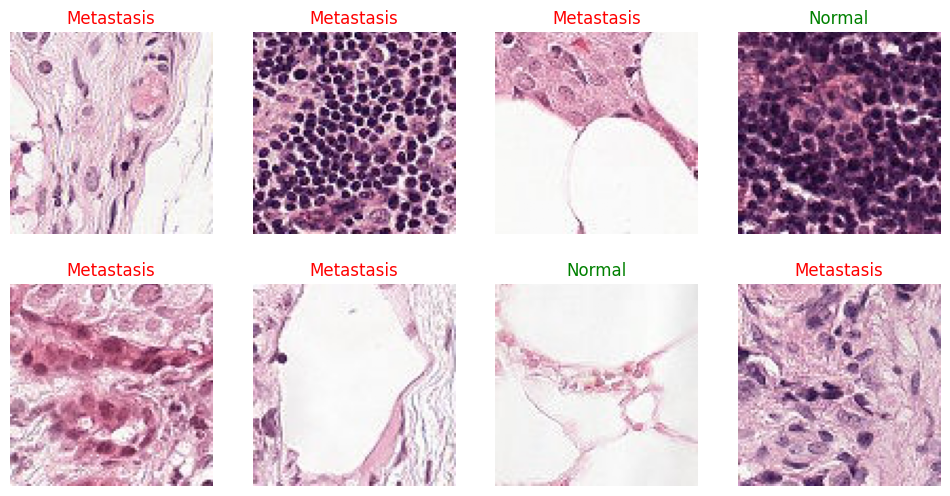

In [27]:
images, labels = train_util.get_batch(0)

plt.figure(figsize=(12, 6))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(images[i])
    
    label_text = "Metastasis" if labels[i][0] == 1 else "Normal"
    color = "red" if labels[i][0] == 1 else "green"
    
    plt.title(label_text, color=color)
    plt.axis('off')
plt.show()

In [15]:
def build_custom_cnn(input_shape=(96, 96, 3)):
    model = models.Sequential()
    
    # Input Block
    model.add(layers.InputLayer(input_shape=input_shape))
    
    # Convolutional Block 1
    model.add(layers.Conv2D(32, (3, 3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(32, (3, 3), padding='same', activation='relu'))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.25))
    
    # Convolutional Block 2
    model.add(layers.Conv2D(64, (3, 3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(64, (3, 3), padding='same', activation='relu'))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.25))
    
    # Convolutional Block 3
    model.add(layers.Conv2D(128, (3, 3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(128, (3, 3), padding='same', activation='relu'))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.4))

    # Flatten and Dense Layers
    model.add(layers.Flatten())
    model.add(layers.Dense(512, activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.5))
    
    # Output Layer (Sigmoid for Binary Classification)
    model.add(layers.Dense(1, activation='sigmoid'))
    
    return model

In [29]:
model = build_custom_cnn()

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy', 'AUC']
)

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)              │ (None, 96, 96, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 96, 96, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 96, 96, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 48, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │     9,437,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,728,161 (37.11 MB)

 Trainable params: 9,726,689 (37.10 MB)

 Non-trainable params: 1,472 (5.75 KB)

In [30]:
checkpoint = ModelCheckpoint(
    'models/model_epoch_{epoch:02d}_val_acc_{val_accuracy:.4f}.h5', 
    monitor='val_accuracy', 
    save_best_only=False, # 
    save_freq='epoch', # Save after every epoch
    mode='max', 
    verbose=1
)

early_stopping = EarlyStopping(
    monitor='val_accuracy', 
    patience=5, 
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.5, 
    patience=2, 
    min_lr=1e-6, 
    verbose=1
)

callbacks_list = [checkpoint, early_stopping, reduce_lr]

In [20]:
EPOCHS = 15

TRAIN_STEPS = len(train_util)
VALID_STEPS = len(valid_util)

history = model.fit(
    train_ds, 
    steps_per_epoch=TRAIN_STEPS,
    validation_data=valid_ds, 
    validation_steps=VALID_STEPS,
    epochs=EPOCHS,
    callbacks=callbacks_list,
    verbose=1
)

Epoch 1/15
2048/2048 ━━━━━━━━━━━━━━━━━━━━ 0s 767ms/step - AUC: 0.9811 - accuracy: 0.9350 - loss: 0.1722
Epoch 1: saving model to models/model_epoch_01_val_acc_0.8233.h5


2048/2048 ━━━━━━━━━━━━━━━━━━━━ 1580s 772ms/step - AUC: 0.9811 - accuracy: 0.9350 - loss: 0.1721 - val_AUC: 0.8723 - val_accuracy: 0.8233 - val_loss: 0.6573 - learning_rate: 0.0010
Epoch 2/15
2048/2048 ━━━━━━━━━━━━━━━━━━━━ 0s 764ms/step - AUC: 0.9855 - accuracy: 0.9443 - loss: 0.1491
Epoch 2: saving model to models/model_epoch_02_val_acc_0.8701.h5


2048/2048 ━━━━━━━━━━━━━━━━━━━━ 1575s 769ms/step - AUC: 0.9855 - accuracy: 0.9443 - loss: 0.1491 - val_AUC: 0.9370 - val_accuracy: 0.8701 - val_loss: 0.3536 - learning_rate: 0.0010
Epoch 3/15
2048/2048 ━━━━━━━━━━━━━━━━━━━━ 0s 764ms/step - AUC: 0.9880 - accuracy: 0.9499 - loss: 0.1353
Epoch 3: saving model to models/model_epoch_03_val_acc_0.8674.h5


2048/2048 ━━━━━━━━━━━━━━━━━━━━ 1577s 770ms/step - AUC: 0.9880 - accuracy: 0.9499 - loss: 0.1353 - val_AUC: 0.9433 - val_accuracy: 0.8674 - val_loss: 0.3217 - learning_rate: 0.0010
Epoch 4/15
2048/2048 ━━━━━━━━━━━━━━━━━━━━ 0s 762ms/step - AUC: 0.9895 - accuracy: 0.9544 - loss: 0.1250
Epoch 4: saving model to models/model_epoch_04_val_acc_0.7280.h5


2048/2048 ━━━━━━━━━━━━━━━━━━━━ 1579s 771ms/step - AUC: 0.9895 - accuracy: 0.9544 - loss: 0.1250 - val_AUC: 0.7583 - val_accuracy: 0.7280 - val_loss: 1.7869 - learning_rate: 0.0010
Epoch 5/15
2048/2048 ━━━━━━━━━━━━━━━━━━━━ 0s 760ms/step - AUC: 0.9908 - accuracy: 0.9574 - loss: 0.1164
Epoch 5: saving model to models/model_epoch_05_val_acc_0.6508.h5



Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
2048/2048 ━━━━━━━━━━━━━━━━━━━━ 1588s 776ms/step - AUC: 0.9908 - accuracy: 0.9574 - loss: 0.1164 - val_AUC: 0.6587 - val_accuracy: 0.6508 - val_loss: 4.5178 - learning_rate: 0.0010
Epoch 6/15
2048/2048 ━━━━━━━━━━━━━━━━━━━━ 0s 752ms/step - AUC: 0.9932 - accuracy: 0.9647 - loss: 0.0987
Epoch 6: saving model to models/model_epoch_06_val_acc_0.8222.h5


2048/2048 ━━━━━━━━━━━━━━━━━━━━ 1595s 779ms/step - AUC: 0.9932 - accuracy: 0.9647 - loss: 0.0987 - val_AUC: 0.8678 - val_accuracy: 0.8222 - val_loss: 0.8344 - learning_rate: 5.0000e-04
Epoch 7/15
2048/2048 ━━━━━━━━━━━━━━━━━━━━ 0s 740ms/step - AUC: 0.9941 - accuracy: 0.9672 - loss: 0.0913
Epoch 7: saving model to models/model_epoch_07_val_acc_0.8601.h5



Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
2048/2048 ━━━━━━━━━━━━━━━━━━━━ 1619s 791ms/step - AUC: 0.9941 - accuracy: 0.9672 - loss: 0.0913 - val_AUC: 0.9243 - val_accuracy: 0.8601 - val_loss: 0.4727 - learning_rate: 5.0000e-04
Epoch 7: early stopping
Restoring model weights from the end of the best epoch: 2.


In [48]:
final= '/kaggle/input/customhisto/tensorflow2/default/1/final_metastasis_detection_model.h5'

try:
    model = tf.keras.models.load_model(final)
    print("Model loaded successfully.")
except Exception as e:
    print(f"Error loading model: {e}")
    model = build_custom_cnn()
    model.compile(
        optimizer=optimizers.Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy', 'AUC']
    )

Model loaded successfully.


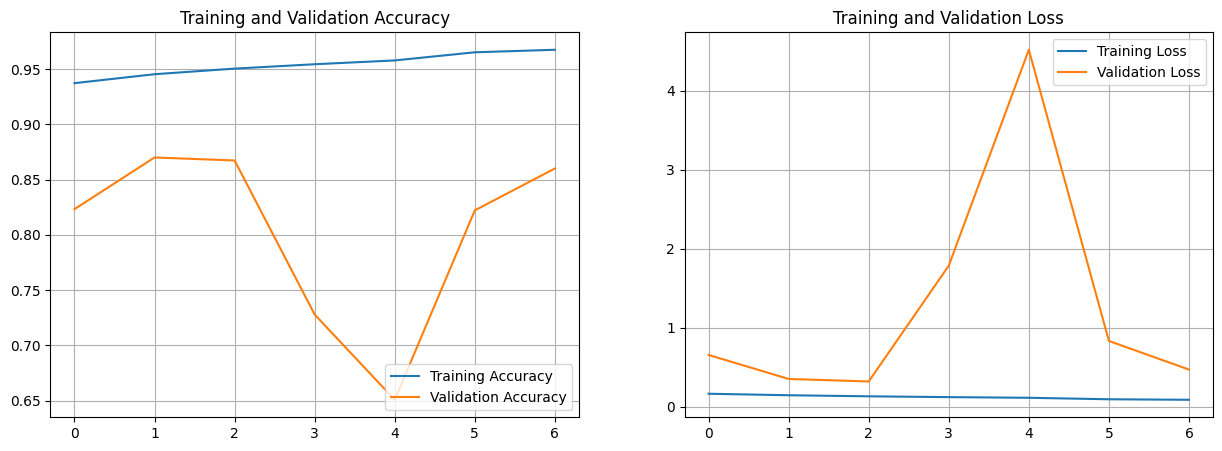

In [32]:
# Plot accuracy and loss
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(15, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.grid(True)

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.grid(True)

plt.show()

In [50]:
TEST_STEPS = len(test_gen)

print("Evaluating on Test Set...")
test_loss, test_acc, test_auc = model.evaluate(test_ds, steps=TEST_STEPS)
print(f"\nTest Accuracy: {test_acc:.4f}")
print(f"Test AUC: {test_auc:.4f}")

Evaluating on Test Set...
256/256 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.8333 - auc_3: 0.9083 - loss: 0.4359

Test Accuracy: 0.8349
Test AUC: 0.9074


256/256 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step
              precision    recall  f1-score   support

      Normal       0.81      0.88      0.84     16391
  Metastasis       0.87      0.79      0.83     16377

    accuracy                           0.83     32768
   macro avg       0.84      0.83      0.83     32768
weighted avg       0.84      0.83      0.83     32768



Text(0.5, 1.0, 'Confusion Matrix')

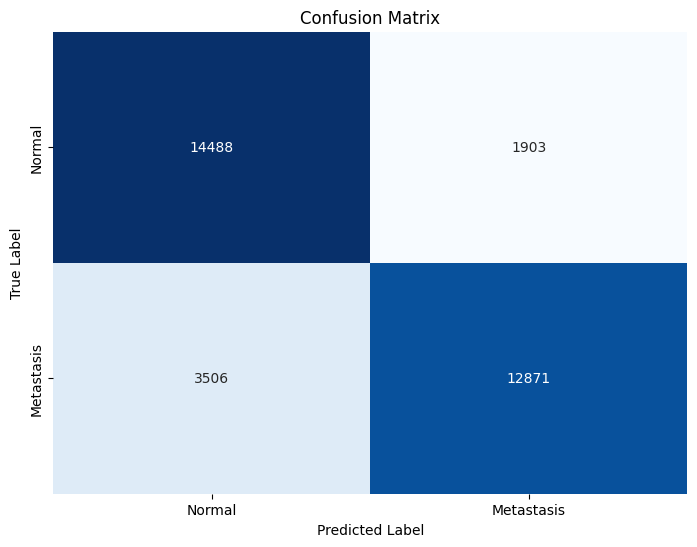

In [52]:
from sklearn.metrics import roc_curve, auc, classification_report, confusion_matrix

TEST_STEPS = len(test_gen)

predictions = model.predict(test_ds, steps=TEST_STEPS)
predicted_classes = (predictions > 0.5).astype("int32")

y_true = []
with h5py.File(test_y_path, 'r') as hf:
    y_true = hf['y'][:len(predicted_classes)].flatten() 

print(classification_report(y_true, predicted_classes, target_names=['Normal', 'Metastasis']))

cm = confusion_matrix(y_true, predicted_classes)
plt.figure(figsize=(18, 6))

plt.subplot(1, 2, 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, 
            xticklabels=['Normal', 'Metastasis'], 
            yticklabels=['Normal', 'Metastasis'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')



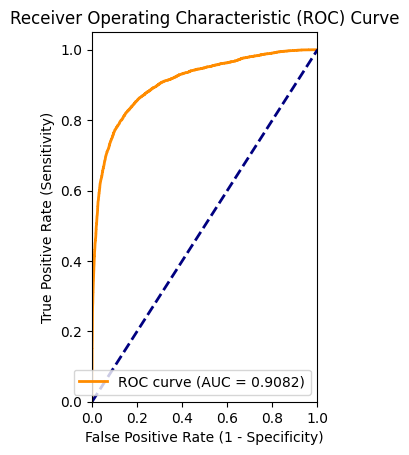

In [53]:
fpr, tpr, thresholds = roc_curve(y_true, predictions)
roc_auc = auc(fpr, tpr)

plt.subplot(1, 2, 2)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right") \

plt.show()

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated a

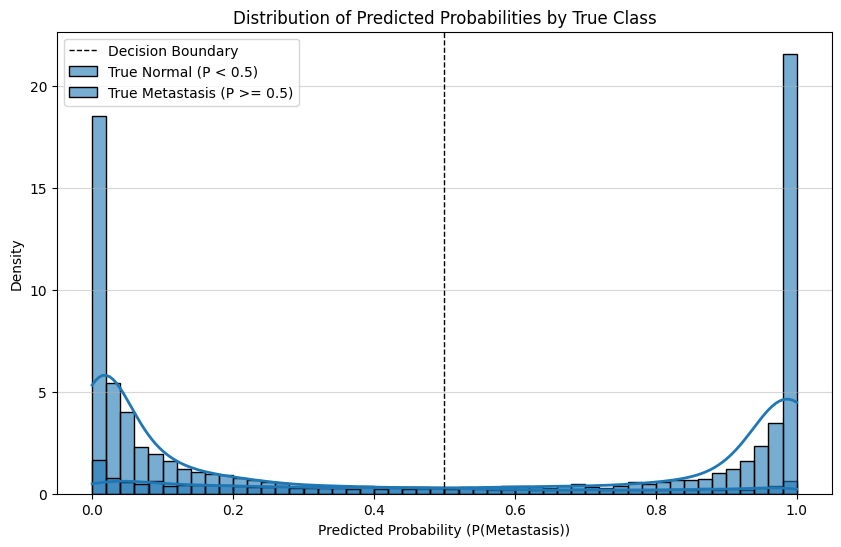

In [60]:
# Predicted Probability Distribution 

if 'predictions' not in locals():
    print("Please run Notebook Cell 12 to generate predictions first.")
else:
    prob_normal = predictions[y_true == 0]
    prob_metastasis = predictions[y_true == 1]

    plt.figure(figsize=(10, 6))
    
    sns.histplot(
        prob_normal, 
        color="green", 
        label="True Normal (P < 0.5)", 
        kde=True, 
        stat="density", 
        line_kws={'lw': 2},
        bins=50,
        alpha=0.6
    )
    
    sns.histplot(
        prob_metastasis, 
        color="red", 
        label="True Metastasis (P >= 0.5)", 
        kde=True, 
        stat="density", 
        line_kws={'lw': 2},
        bins=50,
        alpha=0.6
    )

    plt.title('Distribution of Predicted Probabilities by True Class')
    plt.xlabel('Predicted Probability (P(Metastasis))')
    plt.ylabel('Density')
    plt.axvline(0.5, color='black', linestyle='--', linewidth=1, label='Decision Boundary')
    plt.legend()
    plt.grid(axis='y', alpha=0.5)
    plt.show()

In [37]:
model.save('model.h5')
print("Model saved")

Model saved
